In [1]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.shape

(1025, 14)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [6]:
df['target'].value_counts(normalize=True) * 100

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

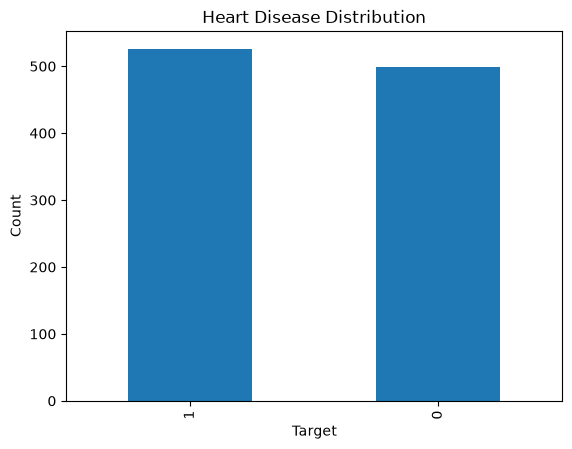

In [7]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

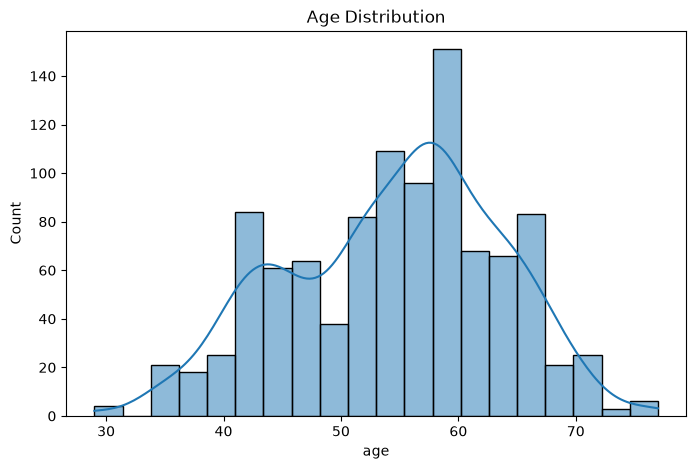

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

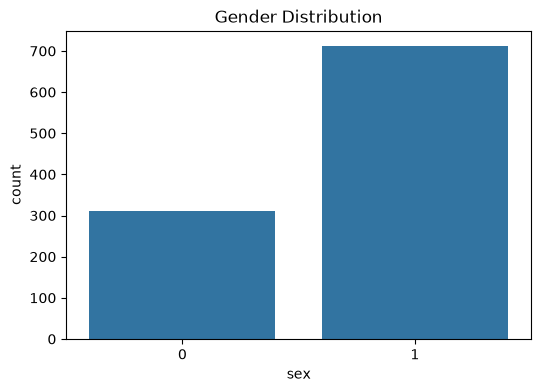

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")
plt.show()

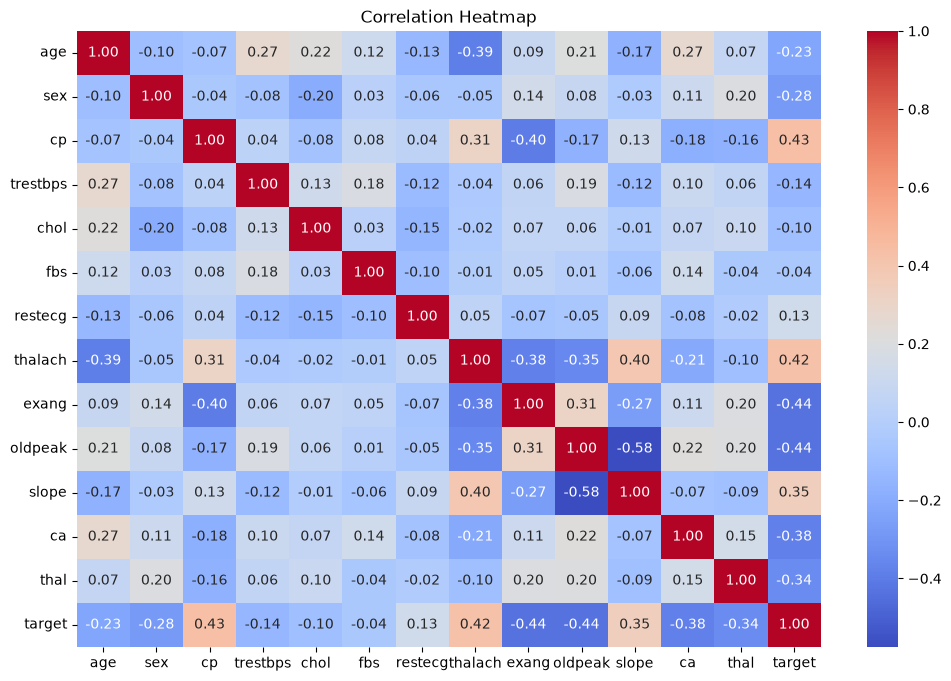

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [14]:
train_score = model.score(X_train, y_train)

print("Training Accuracy:", train_score)

Training Accuracy: 0.8719512195121951


In [15]:
test_score = model.score(X_test, y_test)

print("Testing Accuracy:", test_score)

Testing Accuracy: 0.7951219512195122


In [16]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[73 29]
 [13 90]]


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9853658536585366


In [19]:
print("Training Accuracy:", dt.score(X_train, y_train))
print("Testing Accuracy:", dt.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.9853658536585366


In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt, X, y, cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Average Accuracy: 1.0


In [21]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 723


In [22]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [23]:
df = df.drop_duplicates()

print(df.shape)

(302, 14)


In [24]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [25]:
X = df.drop("target", axis=1)
y = df["target"]

print(X.shape)
print(y.shape)

(302, 13)
(302,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (241, 13)
Testing : (61, 13)


In [27]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Training Accuracy :", lr.score(X_train, y_train))
print("Testing Accuracy  :", lr.score(X_test, y_test))

Training Accuracy : 0.8630705394190872
Testing Accuracy  : 0.8032786885245902


D:\projects\Heart_Disease_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Training Accuracy :", dt.score(X_train, y_train))
print("Testing Accuracy  :", dt.score(X_test, y_test))

Training Accuracy : 1.0
Testing Accuracy  : 0.7377049180327869


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Training Accuracy :", rf.score(X_train, y_train))
print("Testing Accuracy  :", rf.score(X_test, y_test))

Training Accuracy : 1.0
Testing Accuracy  : 0.8360655737704918


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to test data
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[-0.68263287  0.6852096  -0.98005432 -0.40315275  0.48628088 -0.42587856
  -1.02487724  0.71700677 -0.71813875 -0.44752381 -0.71553867 -0.70553555
   1.1181192 ]
 [ 0.40398881  0.6852096  -0.98005432 -0.17140603  0.20631506 -0.42587856
  -1.02487724 -0.83662728  1.39248856  1.76803161 -0.71553867  1.24887901
   1.1181192 ]
 [-1.00861938 -1.45940746 -0.00404981 -0.05553267 -0.26029464 -0.42587856
  -1.02487724  1.10541528 -0.71813875 -0.35890159 -0.71553867 -0.70553555
  -0.54525566]
 [-1.11728155  0.6852096  -0.00404981 -0.63489947 -0.52159607 -0.42587856
   0.86058394  0.88963277 -0.71813875 -0.89063489  0.99183578 -0.70553555
  -0.54525566]
 [ 0.83863748 -1.45940746 -0.98005432  1.10320093 -0.07365076 -0.42587856
   0.86058394  0.19912875  1.39248856  0.35007614 -0.71553867 -0.70553555
  -0.54525566]]


In [31]:
from sklearn.linear_model import LogisticRegression

lr_scaled = LogisticRegression(max_iter=1000)

lr_scaled.fit(X_train_scaled, y_train)

print("Training Accuracy:", lr_scaled.score(X_train_scaled, y_train))
print("Testing Accuracy :", lr_scaled.score(X_test_scaled, y_test))

Training Accuracy: 0.8630705394190872
Testing Accuracy : 0.7704918032786885


In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

In [34]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [35]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}

Best Cross Validation Accuracy:
0.8176870748299321


In [36]:
best_rf = grid.best_estimator_

print("Training Accuracy:",
      best_rf.score(X_train, y_train))

print("Testing Accuracy:",
      best_rf.score(X_test, y_test))

Training Accuracy: 0.8796680497925311
Testing Accuracy: 0.8360655737704918


In [37]:
import pickle
import os

In [38]:
os.makedirs("models", exist_ok=True)

In [39]:
pickle.dump(
    best_rf,
    open("models/heart_model.pkl", "wb")
)

In [40]:
pickle.dump(
    scaler,
    open("models/scaler.pkl", "wb")
)

In [41]:
os.listdir("models")

['heart_model.pkl', 'scaler.pkl']

In [42]:
import os

print(os.getcwd())

D:\projects\Heart_Disease_Prediction\notebooks


In [43]:
os.listdir("models")

['heart_model.pkl', 'scaler.pkl']

In [45]:
import os
import pickle

# Go to project root
project_root = os.path.dirname(os.getcwd())

# Create models folder if needed
os.makedirs(os.path.join(project_root, "models"), exist_ok=True)

# Save model
pickle.dump(
    best_rf,
    open(os.path.join(project_root, "models", "heart_model.pkl"), "wb")
)

# Save scaler
pickle.dump(
    scaler,
    open(os.path.join(project_root, "models", "scaler.pkl"), "wb")
)

print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!
